In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
import sys
from sklearn.metrics import r2_score
from matplotlib.lines import Line2D
from scipy.fft import fft, fftfreq
import xarray as xr

sys.path.append('/Users/kjesta/Desktop/LABDATA/')
sys.path.append('/Users/kjesta/Desktop/Master prosjekt/Master_code/Lab/')
sys.path.append('/Users/kjesta/Desktop/Master prosjekt/Master_code/Lab/Probe_analysis')

from funcs import *
from processing_funcs import *
from analysis_funcs import *

import matplotlib.style as mplstyle
mplstyle.use(["ggplot", "fast"])

import warnings
warnings.filterwarnings("ignore")

%load_ext autoreload
%autoreload 2

# For plotting
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.style as mplstyle
mplstyle.use(['ggplot', 'fast'])

mpl.rcParams['figure.dpi'] = 200
mpl.rcParams['font.size'] = 12
mpl.rcParams['axes.titlesize'] = 14
mpl.rcParams['axes.labelsize'] = 12
mpl.rcParams['xtick.labelsize'] = 12
mpl.rcParams['ytick.labelsize'] = 12

from matplotlib.transforms import ScaledTranslation
from matplotlib.colors import LinearSegmentedColormap
from cmocean import cm as cmo
from matplotlib.lines import Line2D
from matplotlib.colors import Normalize

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Vertical velocity from PIV analysis
## Made from `/PIV/plate_top_rectangular_IR/...`
* IR: 16 x 32 px
* Overlap = 50%
* SA = 16 x 32 px
* stepsize = 3, 5, 7
* sig2noise threshold = 1.2
* max_iter = 10
* kernel_size = 2

In [29]:
base_path = '/Users/kjesta/Desktop/LABDATA/PIV/Results/zoom/Final/'
# Results from PIV processing
# 16 x 32 window size, dt = 3, 5, 7 frames, respectively for the three amplitudes
piv_a03_r1 = xr.open_dataset(base_path + 'f14a03_rec_res_r1.nc')
piv_a03_r2 = xr.open_dataset(base_path + 'f14a03_rec_res_r2.nc')
piv_a03_r3 = xr.open_dataset(base_path + 'f14a03_rec_res_r3.nc')

piv_a02_r1 = xr.open_dataset(base_path + 'f14a02_rec_res_r1.nc')
piv_a02_r2 = xr.open_dataset(base_path + 'f14a02_rec_res_r2.nc')
piv_a02_r3 = xr.open_dataset(base_path + 'f14a02_rec_res_r3.nc')

piv_a01_r1 = xr.open_dataset(base_path + 'f14a01_rec_res_r1.nc')
piv_a01_r2 = xr.open_dataset(base_path + 'f14a01_rec_res_r2.nc')
piv_a01_r3 = xr.open_dataset(base_path + 'f14a01_rec_res_r3.nc')

base_path = '/Users/kjesta/Desktop/LABDATA/Calculated_amps/Amps_250326/'
# Results from probe analysis
no_plates_20 = pd.read_csv(base_path + 'no_plates_20cm.csv')
plates_20 = pd.read_csv(base_path + 'plates_20cm.csv')

f14a03 = no_plates_20[(no_plates_20["frequency"] == 1.4) & (no_plates_20["volt"] == 0.3)]
f14a02 = no_plates_20[(no_plates_20["frequency"] == 1.4) & (no_plates_20["volt"] == 0.2)]
f14a01 = no_plates_20[(no_plates_20["frequency"] == 1.4) & (no_plates_20["volt"] == 0.1)]

f14a03_p = plates_20[(plates_20["frequency"] == 1.4) & (plates_20["volt"] == 0.3)]
f14a02_p = plates_20[(plates_20["frequency"] == 1.4) & (plates_20["volt"] == 0.2)]
f14a01_p = plates_20[(plates_20["frequency"] == 1.4) & (plates_20["volt"] == 0.1)]

del no_plates_20, plates_20

## Observed values

In [30]:
# The time of PIV
# The time is seconds after wave paddle start
# Time range corresponds to ca three wave periods
f=1.4
start = piv_a03_r1.time.values[0]
end = piv_a03_r1.time.values[-1]
time_piv = piv_a03_r1.time.values

print(f"PIV time range: {start:.2f} s to {end:.2f} s")
print(f"Three wave periods: {3/f:.2f} s")

PIV time range: 20.02 s to 22.11 s
Three wave periods: 2.14 s


In [ ]:
# Webers original

def weber_alpha(k, f, D, H):
    h = 0.01
    omega = 2 * np.pi * f
    nu = 1e-6

    return k * (h**2) * omega * (D - H) / (24 * H * nu)

def weber_robin(f, D, H):
    h = 0.01
    omega = 2 * np.pi * f
    nu = 1e-6

    return omega * (h**2) * (D - H) / (12 * nu)

def weber_w_at_plate_top(D, H, A, a, f, k, x, t):
    """
    D = water depth
    H = depth of plate top
    A = wave amplitude at x=0
    a = spatial decay rate of wave amplitude
    f = wave frequency
    k = wave number
    x = horizontal position
    t = time
    """
    omega = 2 * np.pi * f
    theta = k*x - omega*t

    nu = 1e-6
    h = 0.01
    g = 9.81

    term1 = -g * (h**2) * (D - H) * A * np.exp(-a * x) / (12 * nu)
    term2 = ((k**2) * np.cos(theta) - 2 * a * k * np.sin(theta))

    return term1*term2

In [ ]:
# Modified theory

def kjersti_alpha(k, f, D, H):
    h = 0.01
    omega = 2 * np.pi * f
    nu = 1e-6

    nominator = k * omega * (D - H) * 12 * nu / (h**2)
    denominator = 2 * H * ((omega**2) + (144 * (nu**2) / (h**4)))

    return nominator / denominator

def kjersti_robin(f, D, H):
    omega = 2 * np.pi * f
    nu = 1e-6
    h = 0.01

    nominator = omega * (D - H) * (12 * nu / (h**2))
    denominator = omega**2 + (144 * (nu**2) / (h**4))

    return nominator / denominator

def kjersti_w_at_plate_top(D, H, A, a, f, k, x, t):
    """
    D = water depth
    H = depth of plate top
    A = wave amplitude at x=0
    a = spatial decay rate of wave amplitude
    f = wave frequency
    k = wave number
    x = horizontal position
    t = time
    """
    omega = 2 * np.pi * f
    theta = k*x - omega*t

    nu = 1e-6
    h = 0.01
    g = 9.81

    nominator = g * (D - H) * A * np.exp(-a * x)
    denominator = omega**2 + (144 * (nu**2) / (h**4))
    B1 = (12 * (k**2) * nu * np.cos(theta)) / (h**2)
    B2 = -omega * (k**2) * np.sin(theta)
    B3 = -2 * omega * a * k * np.cos(theta)
    B4 = -24 * a * k * nu * np.sin(theta) / (h**2)

    return nominator / denominator * (B1 + B2 + B3 + B4)

In [33]:
# "Normal Airy theory"
# w = d(phi)/dz at z=-H

def airy_w_at_plate_top(A, f, k, D, H, x, t):
    omega = 2*np.pi*f
    return (A*omega) * ((np.sinh(k*(-H + D))/(np.sinh(k*D))))*np.sin(k*x - omega*t - np.pi)

In [34]:
# Mean amplitude at the second probe (P1) for each amplitude
A01 = np.mean([np.mean(f14a01['amp_P1']), np.mean(f14a01_p['amp_P1'])])
A02 = np.mean([np.mean(f14a02['amp_P1']), np.mean(f14a02_p['amp_P1'])])
A03 = np.mean([np.mean(f14a03['amp_P1']), np.mean(f14a03_p['amp_P1'])])

print("Mean measured amplitude at probe 1 (P1):")
print(f"A01 = {A01:.4f} m")
print(f"A02 = {A02:.4f} m")
print(f"A03 = {A03:.4f} m")

# The positions of the probes
# This is the distance from the wave paddle to each probe, in meters
x_probe_pos = np.array([4.86, 6.69, 7.87, 9.15])

# The distance x that the wave travles from probe 1 to end of PIV field
# With 88 points to match the time array of the PIV data, which has 88 time steps

x = np.linspace(8.06 - x_probe_pos[1], 8.06 - x_probe_pos[1] + 0.21, 88) 
print()
print("The wave travels from probe 1 (P1) to the end of the PIV field over a distance of:")
print(f"Distance from probe 1 to start of PIV field: {x[0]:.2f} m")
print(f"Distance from probe 1 to end of PIV field: {x[-1] - x[0]:.2f} m")

Mean measured amplitude at probe 1 (P1):
A01 = 0.0062 m
A02 = 0.0123 m
A03 = 0.0199 m

The wave travels from probe 1 (P1) to the end of the PIV field over a distance of:
Distance from probe 1 to start of PIV field: 1.37 m
Distance from probe 1 to end of PIV field: 0.21 m


In [35]:
f = 1.4  # frequency (Hz)
omega = 2 * np.pi * f  # angular frequency (rad/s)
g = 9.81  # gravitational acceleration (m/s^2)
nu = 1e-6  # kinematic viscosity of water (m^2/s)
D = 0.2  # water height (m)
H = 0.15  # depth of plate top (m)
h = 0.01  # distance between plates (m)
k = estimate_wavenumber(f, D)

In [36]:
a_weber = weber_alpha(k, f, D, H)
a_kjersti = kjersti_alpha(k, f, D, H)

In [37]:
w_weber_a01 = weber_w_at_plate_top(D, H, A01, a_weber, f, k, x, time_piv)
w_kjersti_a01 = kjersti_w_at_plate_top(D, H, A01, a_kjersti, f, k, x, time_piv)

w_weber_a02 = weber_w_at_plate_top(D, H, A02, a_weber, f, k, x, time_piv)
w_kjersti_a02 = kjersti_w_at_plate_top(D, H, A02, a_kjersti, f, k, x, time_piv)

w_weber_a03 = weber_w_at_plate_top(D, H, A03, a_weber, f, k, x, time_piv)
w_kjersti_a03 = kjersti_w_at_plate_top(D, H, A03, a_kjersti, f, k, x, time_piv)

In [38]:
w_airy_a03 = airy_w_at_plate_top(A03, f, k, D, H, x, time_piv)
w_airy_a02 = airy_w_at_plate_top(A02, f, k, D, H, x, time_piv)
w_airy_a01 = airy_w_at_plate_top(A01, f, k, D, H, x, time_piv)

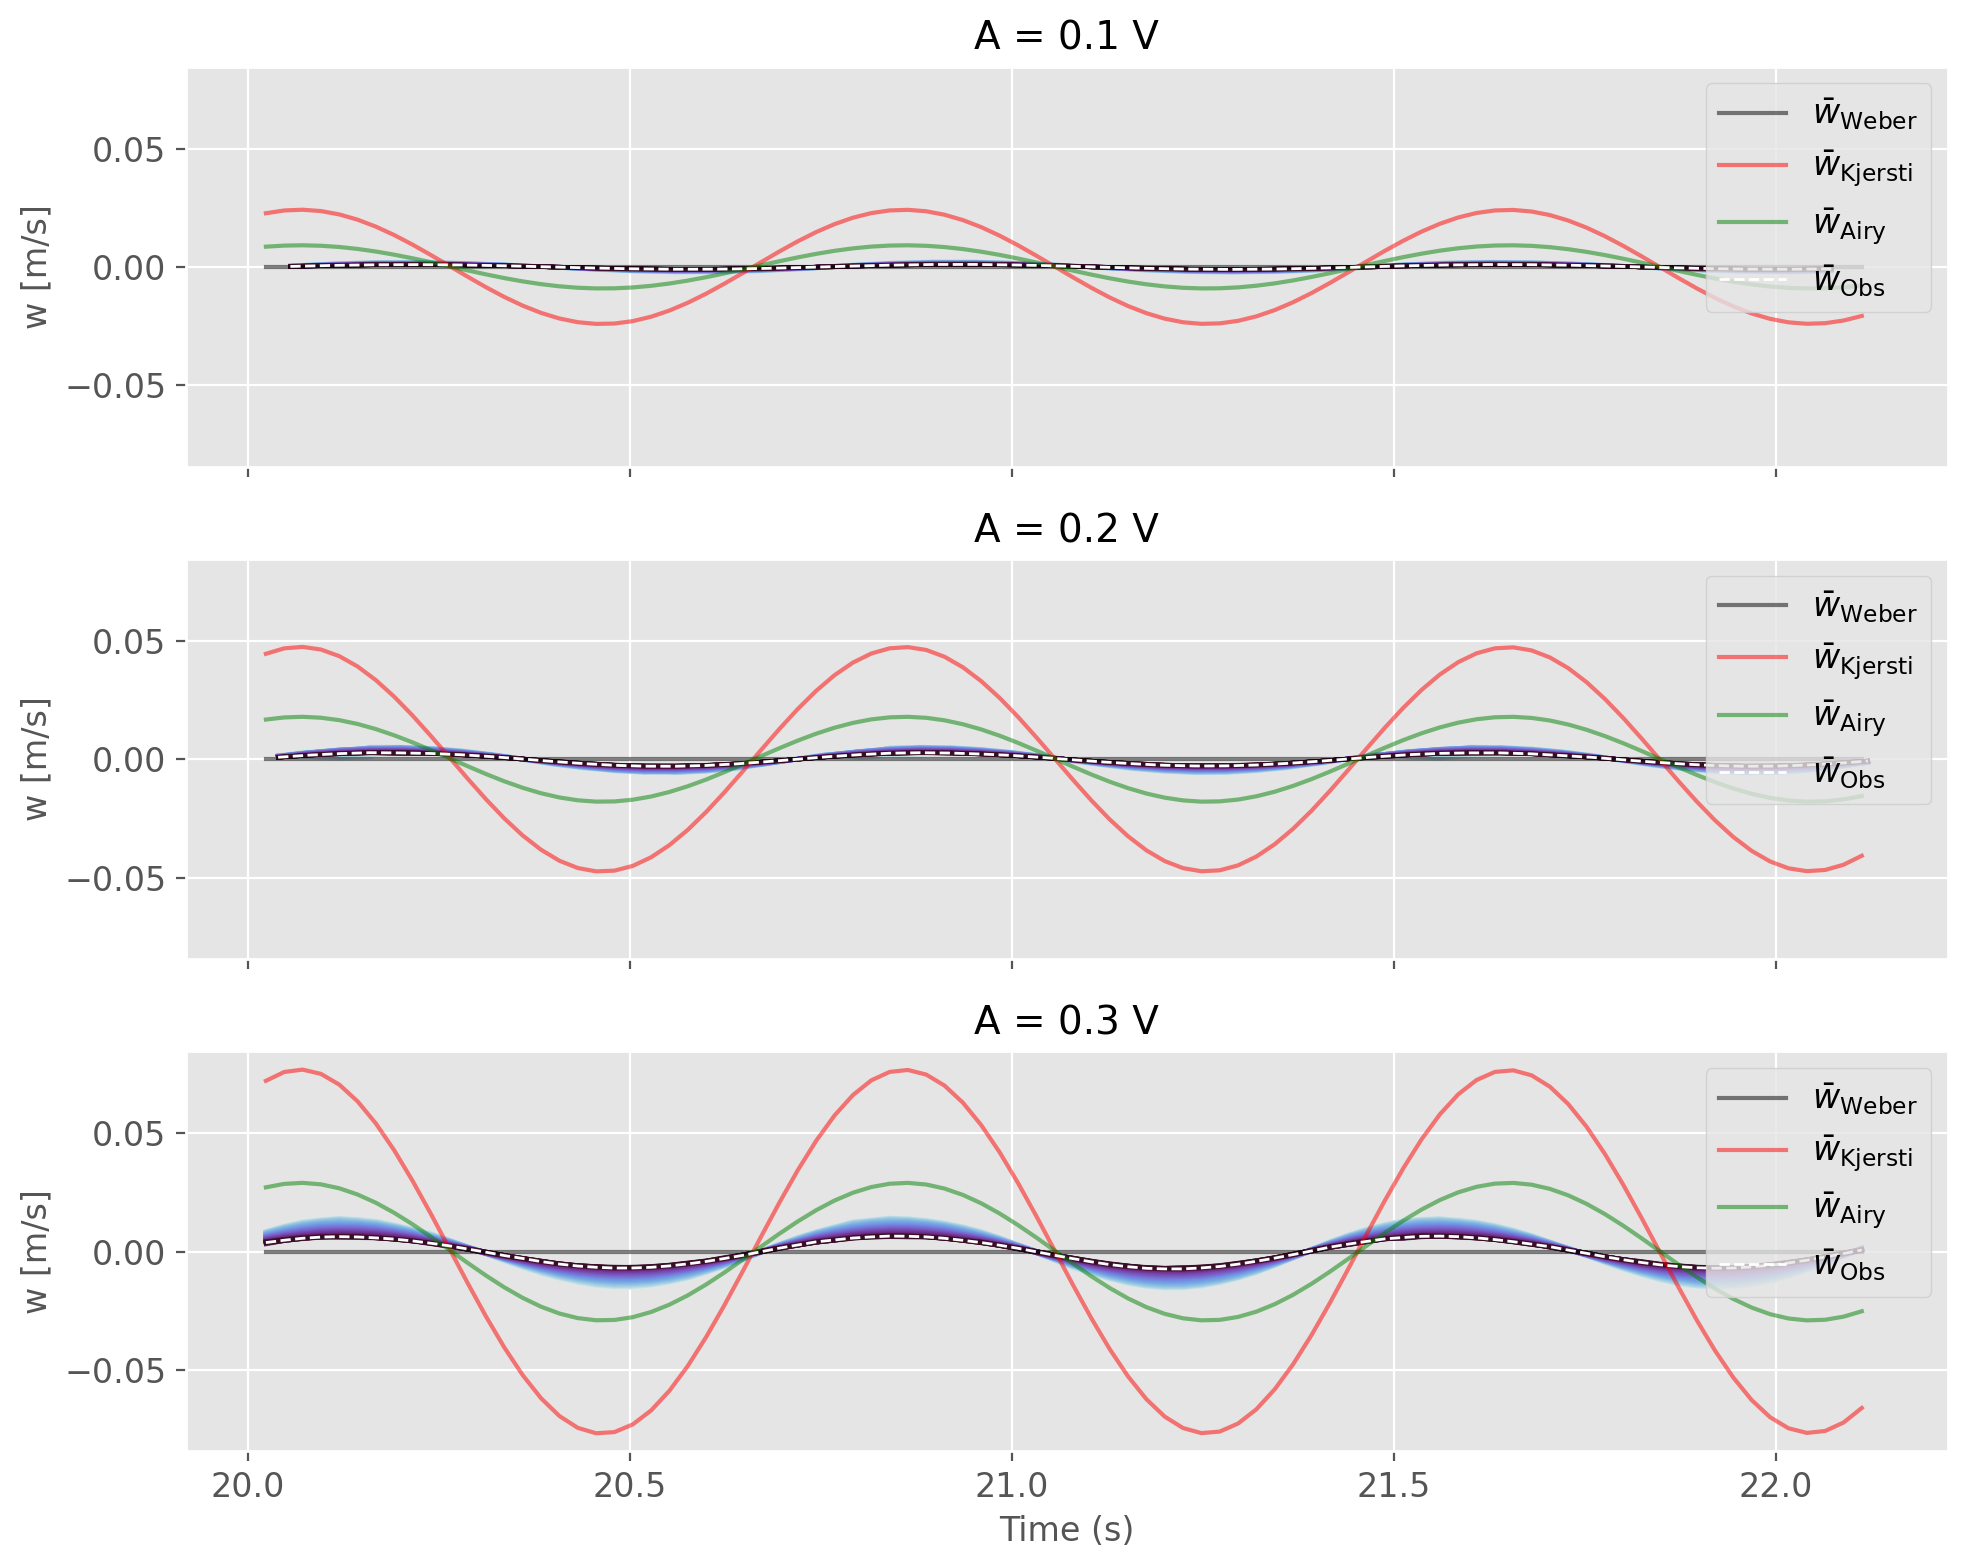

In [39]:
fig, ax = plt.subplots(3, 1, figsize=(10, 8), sharey=True, sharex=True)

# choose a colormap
cmap = cmo.dense
N = 50  # number of lines per subplot

for i in range(N):
    # normalize i to [0, 1] to sample from the colormap
    t = i / (N - 1)
    color = cmap(t)

    # A = 0.1 V
    ax[0].plot(piv_a01_r1.time, piv_a01_r1['w'].mean(axis=2)[:, i],
               color=color, alpha=0.4)
    ax[0].plot(piv_a01_r2.time, piv_a01_r2['w'].mean(axis=2)[:, i],
               color=color, alpha=0.4)
    ax[0].plot(piv_a01_r3.time, piv_a01_r3['w'].mean(axis=2)[:, i],
               color=color, alpha=0.4)

    # A = 0.2 V
    ax[1].plot(piv_a02_r1.time, piv_a02_r1['w'].mean(axis=2)[:, i],
               color=color, alpha=0.4)
    ax[1].plot(piv_a02_r2.time, piv_a02_r2['w'].mean(axis=2)[:, i],
               color=color, alpha=0.4)
    ax[1].plot(piv_a02_r3.time, piv_a02_r3['w'].mean(axis=2)[:, i],
               color=color, alpha=0.4)

    # A = 0.3 V
    ax[2].plot(piv_a03_r1.time, piv_a03_r1['w'].mean(axis=2)[:, i],
               color=color, alpha=0.4)
    ax[2].plot(piv_a03_r2.time, piv_a03_r2['w'].mean(axis=2)[:, i],
               color=color, alpha=0.4)
    ax[2].plot(piv_a03_r3.time, piv_a03_r3['w'].mean(axis=2)[:, i],
               color=color, alpha=0.4)
    
a01_mean = np.mean([piv_a01_r1['w'].mean(axis=2)[:, 42], piv_a01_r2['w'].mean(axis=2)[:, 42], piv_a01_r3['w'].mean(axis=2)[:, 42]], axis=0)
a02_mean = np.mean([piv_a02_r1['w'].mean(axis=2)[:, 42], piv_a02_r2['w'].mean(axis=2)[:, 42], piv_a02_r3['w'].mean(axis=2)[:, 42]], axis=0)
a03_mean = np.mean([piv_a03_r1['w'].mean(axis=2)[:, 42], piv_a03_r2['w'].mean(axis=2)[:, 42], piv_a03_r3['w'].mean(axis=2)[:, 42]], axis=0)

ax[0].plot(time_piv, w_weber_a01, color='black', alpha=0.5, label=r'$\bar{w}_{\text{Weber}}$')
ax[1].plot(time_piv, w_weber_a02, color='black', alpha=0.5, label=r'$\bar{w}_{\text{Weber}}$')
ax[2].plot(time_piv, w_weber_a03, color='black', alpha=0.5, label=r'$\bar{w}_{\text{Weber}}$')

ax[0].plot(time_piv, w_kjersti_a01, color='red', alpha=0.5, label=r'$\bar{w}_{\text{Kjersti}}$')
ax[1].plot(time_piv, w_kjersti_a02, color='red', alpha=0.5, label=r'$\bar{w}_{\text{Kjersti}}$')
ax[2].plot(time_piv, w_kjersti_a03, color='red', alpha=0.5, label=r'$\bar{w}_{\text{Kjersti}}$')

ax[0].plot(time_piv, w_airy_a01, color='green', alpha=0.5, label=r'$\bar{w}_{\text{Airy}}$')
ax[1].plot(time_piv, w_airy_a02, color='green', alpha=0.5, label=r'$\bar{w}_{\text{Airy}}$')
ax[2].plot(time_piv, w_airy_a03, color='green', alpha=0.5, label=r'$\bar{w}_{\text{Airy}}$')

ax[0].plot(piv_a01_r1.time, a01_mean, color='white', linestyle='--', linewidth=1, label=r'$\bar{w}_{\text{Obs}}$')
ax[1].plot(piv_a02_r1.time, a02_mean, color='white', linestyle='--', linewidth=1, label=r'$\bar{w}_{\text{Obs}}$')
ax[2].plot(piv_a03_r1.time, a03_mean, color='white', linestyle='--', linewidth=1, label=r'$\bar{w}_{\text{Obs}}$')

ax[0].set_title('A = 0.1 V')
ax[1].set_title('A = 0.2 V')
ax[2].set_title('A = 0.3 V')
ax[2].set_xlabel('Time (s)')

for a in ax:
    a.set_ylabel('w [m/s]')
    a.legend(loc='upper right')

plt.tight_layout()

## Damping coefficient

In [40]:
no_plates_20 = pd.read_csv("/Users/kjesta/Desktop/LABDATA/Calculated_amps/Amps_250326/no_plates_20cm.csv")
plates_20 = pd.read_csv("/Users/kjesta/Desktop/LABDATA/Calculated_amps/Amps_250326/plates_20cm.csv")
no_plates_30 = pd.read_csv("/Users/kjesta/Desktop/LABDATA/Calculated_amps/Amps_250326/no_plates_30cm.csv")
plates_30 = pd.read_csv("/Users/kjesta/Desktop/LABDATA/Calculated_amps/Amps_250326/plates_30cm.csv")

In [41]:
x_probe_pos = np.array([4.86, 6.69, 7.87, 9.15])  # positions of probes in meters from wave maker
x_prof = x_probe_pos - x_probe_pos[0]  # positions of probes relative to the first probe

In [42]:
f_20 = no_plates_20["frequency"].unique()
f_30 = no_plates_30["frequency"].unique()

D_20 = 0.2
H_20 = 0.15
D_30 = 0.3
H_30 = 0.25

k_20 = []
for f in f_20:
    k_20.append(estimate_wavenumber(f, D_20))
    
k_30 = []
for f in f_30:
    k_30.append(estimate_wavenumber(f, D_30))

In [ ]:
a_weber_20 = []
a_kjersti_20 = []

for k in k_20:
    a_weber_20.append(weber_alpha(k, f_20[0], D_20, H_20))
    a_kjersti_20.append(kjersti_alpha(k, f_20[0], D_20, H_20))

a_weber_30 = []
a_kjersti_30 = []


for k in k_30:
    a_weber_30.append(weber_alpha(k, f_30[0], D_30, H_30))
    a_kjersti_30.append(kjersti_alpha(k, f_30[0], D_30, H_30))


In [44]:
plates_20['alpha_plates'] = plates_20['alpha'] - no_plates_20['alpha']
plates_30['alpha_plates'] = plates_30['alpha'] - no_plates_30['alpha']

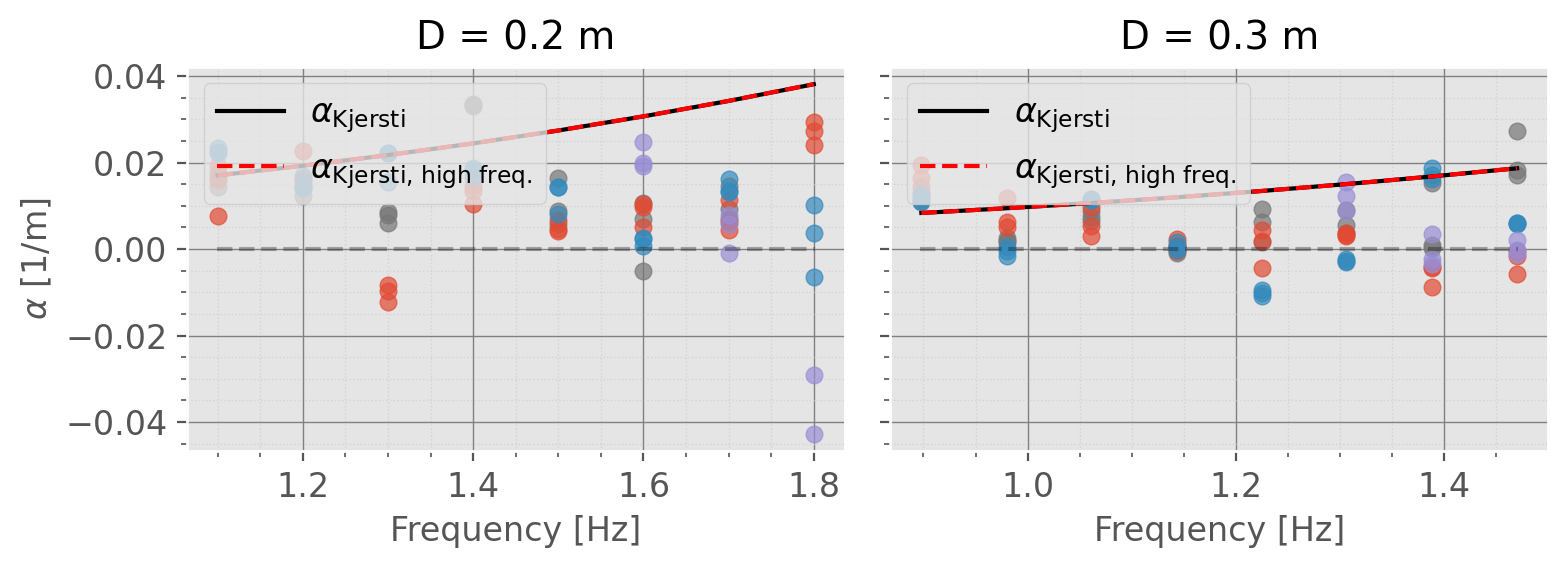

In [49]:
fig, ax = plt.subplots(1, 2, figsize=(8, 3), sharey=True)

level_colors = {
    "low":  "C0",
    "medium":  "C1",
    "medium-high": "C2",
    "high": "C3",
}
ax[0].plot(f_20, np.array(a_kjersti_20), '-', color='black', label=r'$\alpha_{\text{Kjersti}}$')
ax[1].plot(f_30, np.array(a_kjersti_30), '-', color='black', label=r'$\alpha_{\text{Kjersti}}$')

ax[0].plot(f_20, np.array(a_kjersti_20_high_freq), '--', color='red', label=r'$\alpha_{\text{Kjersti, high freq.}}$')
ax[1].plot(f_30, np.array(a_kjersti_30_high_freq), '--', color='red', label=r'$\alpha_{\text{Kjersti, high freq.}}$')

#ax[0].plot(f_20, np.array(a_weber_20), '-', color='blue', label=r'$\alpha_{\text{Weber}}$')
#ax[1].plot(f_30, np.array(a_weber_30), '-', color='blue', label=r'$\alpha_{\text{Weber}}$')

for level, sub in plates_20.groupby("volt_level"):
    ax[0].scatter(sub["frequency"], sub["alpha_plates"],
               marker='o',
               alpha=0.7,
               color=level_colors.get(level, "gray"))

for level, sub in plates_30.groupby("volt_level"):
    ax[1].scatter(sub["frequency"], sub["alpha_plates"],
            alpha=0.7,
               marker='o',
               color=level_colors.get(level, "gray"))

""" ax[0].plot(plates_20['frequency'], plates_20['alpha_plates'], 'o', alpha=0.7, color='C0', label=r'$\alpha_{\text{Obs.}}$')
ax[1].plot(plates_30['frequency'], plates_30['alpha_plates'], 'o', alpha=0.7, color='C1', label=r'$\alpha_{\text{Obs.}}$')"""

ax[0].hlines(0, 1.099, 1.801, colors='k', linestyles='dashed', alpha=0.3)
ax[1].hlines(0, 0.897, 1.471, colors='k', linestyles='dashed', alpha=0.3)

ax[0].set_title('D = 0.2 m')
ax[1].set_title('D = 0.3 m')

ax[0].set_xlabel('Frequency [Hz]')
ax[1].set_xlabel('Frequency [Hz]')
ax[0].set_ylabel(r'$\alpha$ [1/m]')

ax[0].legend(loc='upper left')
ax[1].legend(loc='upper left')

for a in ax:
    a.minorticks_on()
    a.grid(which='major', linestyle='-', linewidth='0.5', color='gray')
    a.grid(which='minor', linestyle=':', linewidth='0.5', color='lightgray') 

plt.tight_layout()